In [7]:
#!/usr/bin/env python3
"""
npy_scalogram_classify_balanced_split_4ch_plus.py  (metrics+plots edition)

Adds:
- Rich metrics for every model (Acc, BalAcc, P/R/F1 macro|micro|weighted, Cohen's kappa, MCC, R^2 on indices*)
- Confusion matrices with labels
- Bar charts comparing models across metrics

*R^2 on class indices is NOT a meaningful classifier metric; printed due to request.
"""

import os, glob, random, json
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier, BernoulliRBM
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef, r2_score
)

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- CONFIG --------------------
SCALOGRAM_ROOT = "scalograms"
ACOUSTIC_DIR   = os.path.join(SCALOGRAM_ROOT, "acoustic")
VIBRATION_DIR  = os.path.join(SCALOGRAM_ROOT, "vibration")

VIB_CH_ORDER = [
    "x_direction_housing_A",
    "y_direction_housing_A",
    "x_direction_housing_B",
    "y_direction_housing_B",
]

TARGET_PER_CONDITION = 24

FREQ_SLICE = (None, 128)
MAX_TIME_COLS_PER_FILE = 20000
COL_STRIDE = 8

PCA_DIM = 128

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS_CNN  = 15
EPOCHS_GRU  = 15
BATCH_SIZE  = 16
BASE_LR     = 3e-4
WEIGHT_DECAY= 1e-2
LABEL_SMOOTH= 0.1
DROPOUT_P   = 0.2
MIXED_PREC  = True
CLIP_NORM   = 1.0

TIME_MASK_PCT = 0.0
FREQ_MASK_PCT = 0.0

GRU_TIME_STRIDE = 2
GRU_TMAX        = 512

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

# -------------------- HELPERS --------------------
def parse_from_meta(meta_path: str):
    with open(meta_path, "r") as fh:
        m = json.load(fh)
    src = m.get("source_csv", "")
    stem = os.path.splitext(os.path.basename(src))[0]
    parts = stem.split("_")
    load = parts[0] if len(parts) > 0 else "UNK"
    cond = parts[1] if len(parts) > 1 else "UNK"
    if cond.lower() == "unbalalnce":
        cond = "Unbalance"
    if cond.lower() == "normal":
        cond = "Normal"
    sev = parts[2] if len(parts) > 2 else "UNK"
    ch  = m.get("channel", None)
    win = int(m.get("window_index", 0))
    return load, cond, sev, ch, win, src

def discover_acoustic_items(acoustic_dir: str) -> List[Tuple[str, str, str]]:
    items = []
    for npy in sorted(glob.glob(os.path.join(acoustic_dir, "*.npy"))):
        meta = npy + ".meta.json"
        if not os.path.exists(meta):
            continue
        try:
            _, cond, sev, _, _, _ = parse_from_meta(meta)
            items.append((npy, cond, sev))
        except Exception:
            pass
    return items

def discover_vibration_groups(vib_dir: str):
    buckets: Dict[Tuple[str,int], Dict[str, Tuple[str,str]]] = {}
    labels: Dict[Tuple[str,int], Tuple[str,str]] = {}
    for npy in sorted(glob.glob(os.path.join(vib_dir, "*.npy"))):
        meta = npy + ".meta.json"
        if not os.path.exists(meta): continue
        try:
            _, cond, sev, ch, win, src = parse_from_meta(meta)
        except Exception:
            continue
        key = (src, win)
        if ch is None:
            continue
        buckets.setdefault(key, {})[ch] = (npy, meta)
        labels[key] = (cond, sev)

    groups: List[List[Tuple[str,str,str]]] = []
    y: List[Tuple[str,str]] = []
    for key, chmap in buckets.items():
        present = [ch for ch in VIB_CH_ORDER if ch in chmap]
        if not present:
            continue
        lst = [(chmap[ch][0], chmap[ch][1], ch) for ch in present]
        groups.append(lst)
        y.append(labels[key])
    return groups, y

def freq_time_thin(power: np.ndarray) -> np.ndarray:
    F0, T0 = power.shape
    fs, fe  = FREQ_SLICE
    f_start = 0 if fs is None else max(0, int(fs))
    f_end   = F0 if fe is None else min(F0, int(fe))
    X = power[f_start:f_end, :]
    if MAX_TIME_COLS_PER_FILE is not None:
        T_cap = min(X.shape[1], MAX_TIME_COLS_PER_FILE)
        X = X[:, :T_cap]
    if COL_STRIDE and COL_STRIDE > 1:
        X = X[:, ::int(COL_STRIDE)]
    return X.astype(np.float32, copy=False)

def load_vibration_group_4ch(group: List[Tuple[str,str,str]]) -> np.ndarray:
    mats = []
    order_present = [ch for ch in VIB_CH_ORDER if any(ch == g[2] for g in group)]
    for ch in order_present:
        npy_path = [g[0] for g in group if g[2] == ch][0]
        arr = np.load(npy_path, mmap_mode="r")
        X = freq_time_thin(arr)
        mats.append(X)
    Tm = min(M.shape[1] for M in mats)
    mats = [M[:, :Tm] for M in mats]
    return np.stack(mats, axis=0)  # (C, F, T)

def load_acoustic_as_4ch(npy_path: str) -> np.ndarray:
    arr = np.load(npy_path, mmap_mode="r")
    X = freq_time_thin(arr)  # (F,T)
    out = np.zeros((4, X.shape[0], X.shape[1]), dtype=np.float32)
    out[0] = X
    return out

# -------------------- BALANCED SAMPLING --------------------
def balanced_select(acoustic_items, vib_groups, vib_labels, k=TARGET_PER_CONDITION):
    from collections import defaultdict
    rng = np.random.default_rng(SEED)
    selected = []

    by_cond_a = defaultdict(list)
    for npy_path, cond, sev in acoustic_items:
        by_cond_a[cond].append((npy_path, cond, sev))
    for cond, lst in by_cond_a.items():
        lst = lst.copy(); rng.shuffle(lst)
        take = lst[:k] if len(lst) >= k else lst
        for npy_path, c, s in take:
            selected.append(("acoustic", npy_path, c, s))

    by_cond_v = defaultdict(list)
    for g, (cond, sev) in zip(vib_groups, vib_labels):
        by_cond_v[cond].append((g, cond, sev))
    for cond, lst in by_cond_v.items():
        lst = lst.copy(); rng.shuffle(lst)
        take = lst[:k] if len(lst) >= k else lst
        for g, c, s in take:
            selected.append(("vibration", g, c, s))

    rng.shuffle(selected)
    return selected

# -------------------- DATASETS --------------------
class NpyDataset4Ch(Dataset):
    def __init__(self, items, cond2id: Dict[str,int], sev2id: Dict[str,int]):
        self.items = items
        self.cond2id = cond2id
        self.sev2id  = sev2id
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        src_type, payload, cond, sev = self.items[i]
        if src_type == "acoustic":
            X = load_acoustic_as_4ch(payload)  # (4,F,T)
        else:
            X = load_vibration_group_4ch(payload)
            if X.shape[0] < 4:
                C, F, T = X.shape
                tmp = np.zeros((4, F, T), dtype=np.float32)
                tmp[:C] = X
                X = tmp
        yc = self.cond2id[cond]
        ys = self.sev2id[sev]
        return torch.from_numpy(X), torch.tensor(yc, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

# -------------------- CLASSICAL FEATURE STACK --------------------
def build_flat_features(items_subset):
    mats = []
    for src_type, payload, _, _ in items_subset:
        if src_type == "acoustic":
            X = load_acoustic_as_4ch(payload)
        else:
            X = load_vibration_group_4ch(payload)
            if X.shape[0] < 4:
                C, F, T = X.shape
                tmp = np.zeros((4, F, T), dtype=np.float32)
                tmp[:C] = X
                X = tmp
        X = np.log1p(X).astype(np.float32)
        mats.append(X.reshape(-1))
    return np.stack(mats)

# -------------------- MODELS --------------------
class CNN2D(nn.Module):
    def __init__(self, n_cond: int, n_sev: int, in_ch: int = 4):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_ch, 32, 5, padding=2, stride=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2,4)), nn.Dropout(DROPOUT_P),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout(DROPOUT_P),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 8)),
        )
        self.flat = nn.Flatten()
        self.fc_cond = nn.Linear(128*4*8, n_cond)
        self.fc_sev  = nn.Linear(128*4*8, n_sev)
    def forward(self, x):
        z = self.backbone(x)
        z = self.flat(z)
        return self.fc_cond(z), self.fc_sev(z)

class GRUClassifier(nn.Module):
    def __init__(self, n_cond: int, n_sev: int, feat_dim: int, hidden: int = 128, layers: int = 2, bidir: bool = True):
        super().__init__()
        self.gru = nn.GRU(
            input_size=feat_dim, hidden_size=hidden, num_layers=layers,
            batch_first=True, dropout=DROPOUT_P if layers > 1 else 0.0, bidirectional=bidir
        )
        mult = 2 if bidir else 1
        self.drop = nn.Dropout(DROPOUT_P)
        self.fc_cond = nn.Linear(hidden*mult, n_cond)
        self.fc_sev  = nn.Linear(hidden*mult, n_sev)
    def forward(self, x):
        x = torch.log1p(torch.clamp(x, min=0))
        mu = x.mean(dim=(2,3), keepdim=True); sd = x.std(dim=(2,3), keepdim=True) + 1e-6
        x = (x - mu) / sd
        B, C, F, T = x.shape
        if GRU_TIME_STRIDE > 1: x = x[..., ::GRU_TIME_STRIDE]
        if x.shape[-1] > GRU_TMAX: x = x[..., :GRU_TMAX]
        B, C, F, T2 = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(B, T2, C*F)
        out, _ = self.gru(x)
        h = out.mean(dim=1)
        h = self.drop(h)
        return self.fc_cond(h), self.fc_sev(h)

# -------------------- TRAIN/EVAL (TORCH) --------------------
def spec_mask(x: torch.Tensor) -> torch.Tensor:
    if TIME_MASK_PCT <= 0 and FREQ_MASK_PCT <= 0: return x
    B, C, F, T = x.shape
    if FREQ_MASK_PCT > 0:
        w = max(1, int(F * FREQ_MASK_PCT))
        for b in range(B):
            f0 = np.random.randint(0, max(1, F - w + 1))
            x[b, :, f0:f0+w, :] = 0
    if TIME_MASK_PCT > 0:
        w = max(1, int(T * TIME_MASK_PCT))
        for b in range(B):
            t0 = np.random.randint(0, max(1, T - w + 1))
            x[b, :, :, t0:t0+w] = 0
    return x

def normalize_batch_per_channel(x: torch.Tensor) -> torch.Tensor:
    x = torch.log1p(torch.clamp(x, min=0))
    mu = x.mean(dim=(2,3), keepdim=True)
    sd = x.std(dim=(2,3), keepdim=True) + 1e-6
    return (x - mu) / sd

def train_multitask(model, dl_tr, dl_va, epochs=15):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=max(1, epochs//2))
    crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and MIXED_PREC))

    best = None; best_val = 1e9; patience=4; wait=0
    for ep in range(1, epochs+1):
        model.train(); tr_sum=0.0; n=0
        for xb, yc, ys in dl_tr:
            xb, yc, ys = xb.to(DEVICE), yc.to(DEVICE), ys.to(DEVICE)
            if isinstance(model, CNN2D):
                xb = normalize_batch_per_channel(xb); xb = spec_mask(xb)
            opt.zero_grad(set_to_none=True)
            if scaler.is_enabled():
                with torch.cuda.amp.autocast():
                    pc, ps = model(xb)
                    loss = crit(pc, yc) + crit(ps, ys)
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                scaler.step(opt); scaler.update()
            else:
                pc, ps = model(xb); loss = crit(pc, yc) + crit(ps, ys)
                loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM); opt.step()
            n += xb.size(0); tr_sum += float(loss.item()) * xb.size(0)
            sched.step(ep - 1 + n / max(1, len(dl_tr.dataset)))
        tr = tr_sum / max(1, n)
        model.eval(); va_sum=0.0; nva=0
        with torch.no_grad():
            for xb, yc, ys in dl_va:
                xb, yc, ys = xb.to(DEVICE), yc.to(DEVICE), ys.to(DEVICE)
                if isinstance(model, CNN2D): xb = normalize_batch_per_channel(xb)
                pc, ps = model(xb)
                loss = nn.functional.cross_entropy(pc, yc) + nn.functional.cross_entropy(ps, ys)
                va_sum += float(loss.item()) * xb.size(0); nva += xb.size(0)
        va = va_sum / max(1,nva)
        print(f"[{model.__class__.__name__}] epoch {ep:02d}  train={tr:.4f}  val={va:.4f}")
        if va < best_val - 1e-6:
            best_val = va; best = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait += 1
            if wait >= patience:
                print("  early stop"); break
    if best is not None: model.load_state_dict(best)
    return model

def eval_multitask(model, dl):
    model.eval(); yc_true, yc_pred, ys_true, ys_pred = [], [], [], []
    with torch.no_grad():
        for xb, yc, ys in dl:
            xb = xb.to(DEVICE)
            if isinstance(model, CNN2D): xb = normalize_batch_per_channel(xb)
            pc, ps = model(xb)
            yc_pred.extend(pc.argmax(1).cpu().numpy().tolist())
            ys_pred.extend(ps.argmax(1).cpu().numpy().tolist())
            yc_true.extend(yc.numpy().tolist())
            ys_true.extend(ys.numpy().tolist())
    return np.array(yc_true), np.array(yc_pred), np.array(ys_true), np.array(ys_pred)

# -------------------- METRICS / PLOTTING --------------------
def all_classif_metrics(y_true, y_pred, label_names=None):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    # macro/micro/weighted P/R/F1
    for avg in ["macro", "micro", "weighted"]:
        metrics[f"precision_{avg}"] = precision_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f"recall_{avg}"]    = recall_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f"f1_{avg}"]        = f1_score(y_true, y_pred, average=avg, zero_division=0)
    # others
    metrics["cohen_kappa"] = cohen_kappa_score(y_true, y_pred)
    metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
    # R^2 on indices (not meaningful for classification)
    metrics["r2_labels_as_int"] = r2_score(y_true, y_pred)
    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm

def print_confusion(cm, label_names, title):
    print(f"\n{title} — Confusion Matrix (rows=true, cols=pred):")
    # pretty print with labels
    header = " " * 16 + " ".join([f"{name:>10s}" for name in label_names])
    print(header)
    for i, row in enumerate(cm):
        row_str = " ".join([f"{v:>10d}" for v in row])
        print(f"{label_names[i]:>14s}  {row_str}")

def plot_metric_bars(metric_table: Dict[str, Dict[str, float]], out_dir="metrics_plots"):
    """
    metric_table: {metric_name: {model_label: value}}
    Produces one bar chart per metric, saved to out_dir.
    """
    os.makedirs(out_dir, exist_ok=True)
    for metric, model_vals in metric_table.items():
        labels = list(model_vals.keys())
        vals = [model_vals[k] for k in labels]
        plt.figure(figsize=(10, 4))
        plt.bar(labels, vals)
        plt.title(metric.replace("_", " ").title())
        plt.xticks(rotation=20, ha="right")
        plt.ylabel("Score")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{metric}.png"), dpi=150)
        plt.close()

In [8]:
# -------------------- PIPELINE --------------------
# Discover items
acoustic_items = discover_acoustic_items(ACOUSTIC_DIR)
vib_groups, vib_labels = discover_vibration_groups(VIBRATION_DIR)
if not acoustic_items and not vib_groups:
    print("[ERROR] No .npy scalograms found.");

# Vocabulary
conditions = sorted(set([c for _, c, _ in acoustic_items] + [c for (c, _) in vib_labels]))
severities = sorted(set([s for _, _, s in acoustic_items] + [s for (_, s) in vib_labels]))
cond2id = {c:i for i,c in enumerate(conditions)}
sev2id  = {s:i for i,s in enumerate(severities)}

# Balanced selection per modality & condition
selected = balanced_select(acoustic_items, vib_groups, vib_labels, k=TARGET_PER_CONDITION)
if not selected:
    selected = [("acoustic", npy, c, s) for (npy, c, s) in acoustic_items] + \
               [("vibration", g, c, s) for g, (c, s) in zip(vib_groups, vib_labels)]

# Stratified split by condition
y_cond = np.array([cond2id[c] for (_, _, c, _) in selected], dtype=np.int64)
idx = np.arange(len(selected))
def safe_split(indices, strat_labels, test_size):
    try: return train_test_split(indices, test_size=test_size, random_state=SEED, stratify=strat_labels)
    except Exception: return train_test_split(indices, test_size=test_size, random_state=SEED)
tr_idx, te_idx = safe_split(idx, y_cond, test_size=0.15)
tr_idx, va_idx = safe_split(tr_idx, y_cond[tr_idx], test_size=0.1765)  # ~70/15/15

tr_items = [selected[i] for i in tr_idx]
va_items = [selected[i] for i in va_idx]
te_items = [selected[i] for i in te_idx]

# Datasets & loaders for neural models
ds_tr = NpyDataset4Ch(tr_items, cond2id, sev2id)
ds_va = NpyDataset4Ch(va_items, cond2id, sev2id)
ds_te = NpyDataset4Ch(te_items, cond2id, sev2id)
dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ===== Classical feature stack (PCA) =====
print("\n[Build PCA features for classical models]")
Xtr_f = build_flat_features(tr_items)
Xva_f = build_flat_features(va_items)
Xte_f = build_flat_features(te_items)

std = StandardScaler(with_mean=True, with_std=True)
Xtr_s = std.fit_transform(Xtr_f); Xva_s = std.transform(Xva_f); Xte_s = std.transform(Xte_f)
pca = PCA(n_components=min(PCA_DIM, Xtr_s.shape[1]), random_state=SEED)
Xtr_p = pca.fit_transform(Xtr_s); Xva_p = pca.transform(Xva_s); Xte_p = pca.transform(Xte_s)

yctr = np.array([cond2id[c] for (_,_,c,_) in tr_items], dtype=np.int64)
ycva = np.array([cond2id[c] for (_,_,c,_) in va_items], dtype=np.int64)
ycte = np.array([cond2id[c] for (_,_,c,_) in te_items], dtype=np.int64)

# Collect metrics for plotting
metric_table = {}  # {metric_name: {model_label: value}}
def add_metrics_to_table(prefix, metrics):
    for k, v in metrics.items():
        metric_table.setdefault(k, {})[prefix] = float(v)

# ===== BPNN (MLP) baseline =====
mlp = MLPClassifier(hidden_layer_sizes=(256,128), activation="relu", max_iter=600, random_state=SEED)
mlp.fit(Xtr_p, yctr)
ypred_mlp = mlp.predict(Xte_p)
m_mlp, cm_mlp = all_classif_metrics(ycte, ypred_mlp, conditions)
print("\n=== Classical models on PCA features ===")
print(f"BPNN(cond) | Acc={m_mlp['accuracy']:.3f}  F1(macro)={m_mlp['f1_macro']:.3f}")
print_confusion(cm_mlp, conditions, "BPNN (Condition)")
add_metrics_to_table("BPNN(cond)", m_mlp)

# ===== SVM (RBF) =====
svm = SVC(C=4.0, gamma="scale", kernel="rbf", class_weight="balanced", random_state=SEED)
svm.fit(Xtr_p, yctr)
ypred_svm = svm.predict(Xte_p)
m_svm, cm_svm = all_classif_metrics(ycte, ypred_svm, conditions)
print(f"SVM (cond) | Acc={m_svm['accuracy']:.3f}  F1(macro)={m_svm['f1_macro']:.3f}")
print_confusion(cm_svm, conditions, "SVM (Condition)")
add_metrics_to_table("SVM(cond)", m_svm)

# ===== ELM =====
class ELMClassifier:
    def __init__(self, n_hidden=512, alpha=1e-2, activation="relu", seed=SEED):
        self.n_hidden=n_hidden; self.alpha=alpha; self.activation=activation
        self.rng=np.random.default_rng(seed); self.W=None; self.b=None; self.beta=None
    def _act(self, Z):
        if self.activation=="relu": return np.maximum(0,Z)
        elif self.activation=="tanh": return np.tanh(Z)
        else: return Z
    def fit(self, X, y):
        n,d=X.shape; classes=np.unique(y); self.classes_=classes; k=classes.size
        Y=np.zeros((n,k)); 
        for i,c in enumerate(classes): Y[y==c,i]=1.0
        self.W=self.rng.standard_normal((d,self.n_hidden))/np.sqrt(d)
        self.b=self.rng.standard_normal((self.n_hidden,))
        H=self._act(X @ self.W + self.b)
        A = H.T @ H + self.alpha*np.eye(self.n_hidden)
        B = H.T @ Y
        self.beta = np.linalg.solve(A,B)
    def predict(self, X):
        H=self._act(X @ self.W + self.b); logits=H @ self.beta
        return self.classes_[np.argmax(logits, axis=1)]

elm = ELMClassifier(n_hidden=512, alpha=1e-2, activation="relu", seed=SEED)
elm.fit(Xtr_p, yctr)
ypred_elm = elm.predict(Xte_p)
m_elm, cm_elm = all_classif_metrics(ycte, ypred_elm, conditions)
print(f"ELM (cond) | Acc={m_elm['accuracy']:.3f}  F1(macro)={m_elm['f1_macro']:.3f}")
print_confusion(cm_elm, conditions, "ELM (Condition)")
add_metrics_to_table("ELM(cond)", m_elm)

# ===== DBN (RBM stack + LR) =====
mm = MinMaxScaler()
Xtr_b = mm.fit_transform(Xtr_p); Xva_b = mm.transform(Xva_p); Xte_b = mm.transform(Xte_p)
rbm1 = BernoulliRBM(n_components=256, learning_rate=0.05, n_iter=20, batch_size=32, random_state=SEED, verbose=False)
rbm2 = BernoulliRBM(n_components=128, learning_rate=0.05, n_iter=20, batch_size=32, random_state=SEED, verbose=False)
lr   = LogisticRegression(max_iter=200, class_weight="balanced", random_state=SEED)
dbn = Pipeline(steps=[("rbm1", rbm1), ("rbm2", rbm2), ("lr", lr)])
dbn.fit(Xtr_b, yctr)
ypred_dbn = dbn.predict(Xte_b)
m_dbn, cm_dbn = all_classif_metrics(ycte, ypred_dbn, conditions)
print(f"DBN (cond) | Acc={m_dbn['accuracy']:.3f}  F1(macro)={m_dbn['f1_macro']:.3f}")
print_confusion(cm_dbn, conditions, "DBN (Condition)")
add_metrics_to_table("DBN(cond)", m_dbn)

# ===== AE + Logistic Regression =====
class AE(nn.Module):
    def __init__(self, in_dim=128, bottleneck=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim,128), nn.ReLU(), nn.Linear(128,64), nn.ReLU(), nn.Linear(64,bottleneck))
        self.dec = nn.Sequential(nn.Linear(bottleneck,64), nn.ReLU(), nn.Linear(64,128), nn.ReLU(), nn.Linear(128,in_dim))
    def forward(self,x):
        z=self.enc(x); r=self.dec(z); return r,z

def train_autoencoder(Xtr_p, Xva_p, epochs=40, lr=1e-3, bottleneck=32):
    device=DEVICE
    Xtr=torch.from_numpy(Xtr_p.astype(np.float32)).to(device)
    Xva=torch.from_numpy(Xva_p.astype(np.float32)).to(device)
    model=AE(in_dim=Xtr.shape[1], bottleneck=bottleneck).to(device)
    opt=torch.optim.Adam(model.parameters(), lr=lr)
    best=None; best_val=1e9; wait=0; patience=6
    for ep in range(1,epochs+1):
        model.train(); opt.zero_grad(); r,z=model(Xtr); loss=nn.functional.mse_loss(r,Xtr)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            rv,zv=model(Xva); vloss=nn.functional.mse_loss(rv,Xva).item()
        print(f"[AE] epoch {ep:02d} train={loss.item():.5f} val={vloss:.5f}")
        if vloss<best_val-1e-6: best_val=vloss; best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait+=1
            if wait>=patience: print("  AE early stop"); break
    if best: model.load_state_dict(best)
    model.eval()
    with torch.no_grad():
        _, Ztr=model(Xtr); _, Zva=model(Xva)
    return model, Ztr.cpu().numpy(), Zva.cpu().numpy()

ae, Ztr, Zva = train_autoencoder(Xtr_p, Xva_p, epochs=50, lr=1e-3, bottleneck=32)
Zte = ae.enc(torch.from_numpy(Xte_p.astype(np.float32)).to(DEVICE)).detach().cpu().numpy()
ae_lr = LogisticRegression(max_iter=200, class_weight="balanced", random_state=SEED)
ae_lr.fit(Ztr, yctr)
ypred_ae = ae_lr.predict(Zte)
m_ae, cm_ae = all_classif_metrics(ycte, ypred_ae, conditions)
print(f"AE+LR(cond) | Acc={m_ae['accuracy']:.3f}  F1(macro)={m_ae['f1_macro']:.3f}")
print_confusion(cm_ae, conditions, "AE+LR (Condition)")
add_metrics_to_table("AE+LR(cond)", m_ae)

# ===== CNN (4-ch, multitask) =====
print("\n=== Neural models (multitask) ===")
cnn = CNN2D(n_cond=len(conditions), n_sev=len(severities), in_ch=4)
cnn = train_multitask(cnn, dl_tr, dl_va, epochs=EPOCHS_CNN)
yc_true, yc_pred, ys_true, ys_pred = eval_multitask(cnn, dl_te)

m_cnn_c, cm_cnn_c = all_classif_metrics(yc_true, yc_pred, conditions)
m_cnn_s, cm_cnn_s = all_classif_metrics(ys_true, ys_pred, severities)
print(f"CNN(cond) | Acc={m_cnn_c['accuracy']:.3f}  F1(macro)={m_cnn_c['f1_macro']:.3f}")
print_confusion(cm_cnn_c, conditions, "CNN (Condition)")
print(f"CNN(sev)  | Acc={m_cnn_s['accuracy']:.3f}  F1(macro)={m_cnn_s['f1_macro']:.3f}")
print_confusion(cm_cnn_s, severities, "CNN (Severity)")
add_metrics_to_table("CNN(cond)", m_cnn_c)
add_metrics_to_table("CNN(sev)",  m_cnn_s)

# ===== GRU (sequence over time, multitask) =====
def collate_constant_F(batch):
    Fs = [x[0].shape[1] for x in batch]
    Fm = min(Fs)
    Xs = [x[0][:, :Fm, :] for x in batch]
    X = torch.stack(Xs, dim=0)
    ycs = torch.stack([y for _, y, _ in batch], dim=0)
    yss = torch.stack([y for _, _, y in batch], dim=0)
    return X, ycs, yss

dl_tr_gru = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_constant_F)
dl_va_gru = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_constant_F)
dl_te_gru = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_constant_F)

X0, _, _ = next(iter(dl_tr_gru))
feat_dim = X0.shape[1] * X0.shape[2]  # 4 * F
gru = GRUClassifier(n_cond=len(conditions), n_sev=len(severities), feat_dim=feat_dim, hidden=128, layers=2, bidir=True).to(DEVICE)
gru = train_multitask(gru, dl_tr_gru, dl_va_gru, epochs=EPOCHS_GRU)
yc_true_g, yc_pred_g, ys_true_g, ys_pred_g = eval_multitask(gru, dl_te_gru)

m_gru_c, cm_gru_c = all_classif_metrics(yc_true_g, yc_pred_g, conditions)
m_gru_s, cm_gru_s = all_classif_metrics(ys_true_g, ys_pred_g, severities)
print(f"GRU(cond) | Acc={m_gru_c['accuracy']:.3f}  F1(macro)={m_gru_c['f1_macro']:.3f}")
print_confusion(cm_gru_c, conditions, "GRU (Condition)")
print(f"GRU(sev)  | Acc={m_gru_s['accuracy']:.3f}  F1(macro)={m_gru_s['f1_macro']:.3f}")
print_confusion(cm_gru_s, severities, "GRU (Severity)")
add_metrics_to_table("GRU(cond)", m_gru_c)
add_metrics_to_table("GRU(sev)",  m_gru_s)

# ===== Plots =====
print("\nSaving metric comparison plots to metrics_plots/ ...")
plot_metric_bars(metric_table, out_dir="metrics_plots")

print("\nDone.")


[Build PCA features for classical models]

=== Classical models on PCA features ===
BPNN(cond) | Acc=0.828  F1(macro)=0.812

BPNN (Condition) — Confusion Matrix (rows=true, cols=pred):
                      BPFI       BPFO   Misalign     Normal  Unbalance
          BPFI           7          0          0          0          0
          BPFO           0          7          0          0          0
      Misalign           0          0          4          0          0
        Normal           0          0          0          2          5
     Unbalance           0          0          0          0          4
SVM (cond) | Acc=0.862  F1(macro)=0.849

SVM (Condition) — Confusion Matrix (rows=true, cols=pred):
                      BPFI       BPFO   Misalign     Normal  Unbalance
          BPFI           7          0          0          0          0
          BPFO           0          6          0          1          0
      Misalign           0          0          4          0          0
    

D:\Sahishnu\VIT\TY\Sem 5\ML\CP\ML_CP\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\gsahi\AppData\Local\Temp\ipykernel_20192\917717036.py:308: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and MIXED_PREC))
C:\Users\gsahi\AppData\Local\Temp\ipykernel_20192\917717036.py:319: FutureWarning: `torch.cuda.amp.autocast(args...)` is de

[CNN2D] epoch 01  train=3.5505  val=3.3504
[CNN2D] epoch 02  train=3.1205  val=2.9556
[CNN2D] epoch 03  train=2.8570  val=2.6911
[CNN2D] epoch 04  train=2.6853  val=2.4829
[CNN2D] epoch 05  train=2.5469  val=2.3694
[CNN2D] epoch 06  train=2.5417  val=2.3111
[CNN2D] epoch 07  train=2.4803  val=2.3206
[CNN2D] epoch 08  train=2.4269  val=1.9633
[CNN2D] epoch 09  train=2.2031  val=1.7333
[CNN2D] epoch 10  train=2.0632  val=1.6395
[CNN2D] epoch 11  train=1.9285  val=1.5649
[CNN2D] epoch 12  train=1.8692  val=1.5012
[CNN2D] epoch 13  train=1.8262  val=1.4738
[CNN2D] epoch 14  train=1.8186  val=1.4772
[CNN2D] epoch 15  train=1.8186  val=1.4164
CNN(cond) | Acc=0.862  F1(macro)=0.756

CNN (Condition) — Confusion Matrix (rows=true, cols=pred):
                      BPFI       BPFO   Misalign     Normal  Unbalance
          BPFI           7          0          0          0          0
          BPFO           0          7          0          0          0
      Misalign           0          0      

C:\Users\gsahi\AppData\Local\Temp\ipykernel_20192\917717036.py:308: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and MIXED_PREC))
C:\Users\gsahi\AppData\Local\Temp\ipykernel_20192\917717036.py:319: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[GRUClassifier] epoch 01  train=3.4609  val=3.1359
[GRUClassifier] epoch 02  train=3.0615  val=2.7985
[GRUClassifier] epoch 03  train=2.7879  val=2.5744
[GRUClassifier] epoch 04  train=2.6115  val=2.3908
[GRUClassifier] epoch 05  train=2.5059  val=2.2847
[GRUClassifier] epoch 06  train=2.4371  val=2.2449
[GRUClassifier] epoch 07  train=2.4193  val=2.2388
[GRUClassifier] epoch 08  train=2.3347  val=1.9355
[GRUClassifier] epoch 09  train=2.1121  val=1.6967
[GRUClassifier] epoch 10  train=1.9476  val=1.5212
[GRUClassifier] epoch 11  train=1.8346  val=1.4189
[GRUClassifier] epoch 12  train=1.7659  val=1.3697
[GRUClassifier] epoch 13  train=1.7266  val=1.3468
[GRUClassifier] epoch 14  train=1.7288  val=1.3434
[GRUClassifier] epoch 15  train=1.6874  val=1.1897
GRU(cond) | Acc=0.897  F1(macro)=0.845

GRU (Condition) — Confusion Matrix (rows=true, cols=pred):
                      BPFI       BPFO   Misalign     Normal  Unbalance
          BPFI           7          0          0          0      

C:\Users\gsahi\AppData\Local\Temp\ipykernel_20192\1821880618.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_cm.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


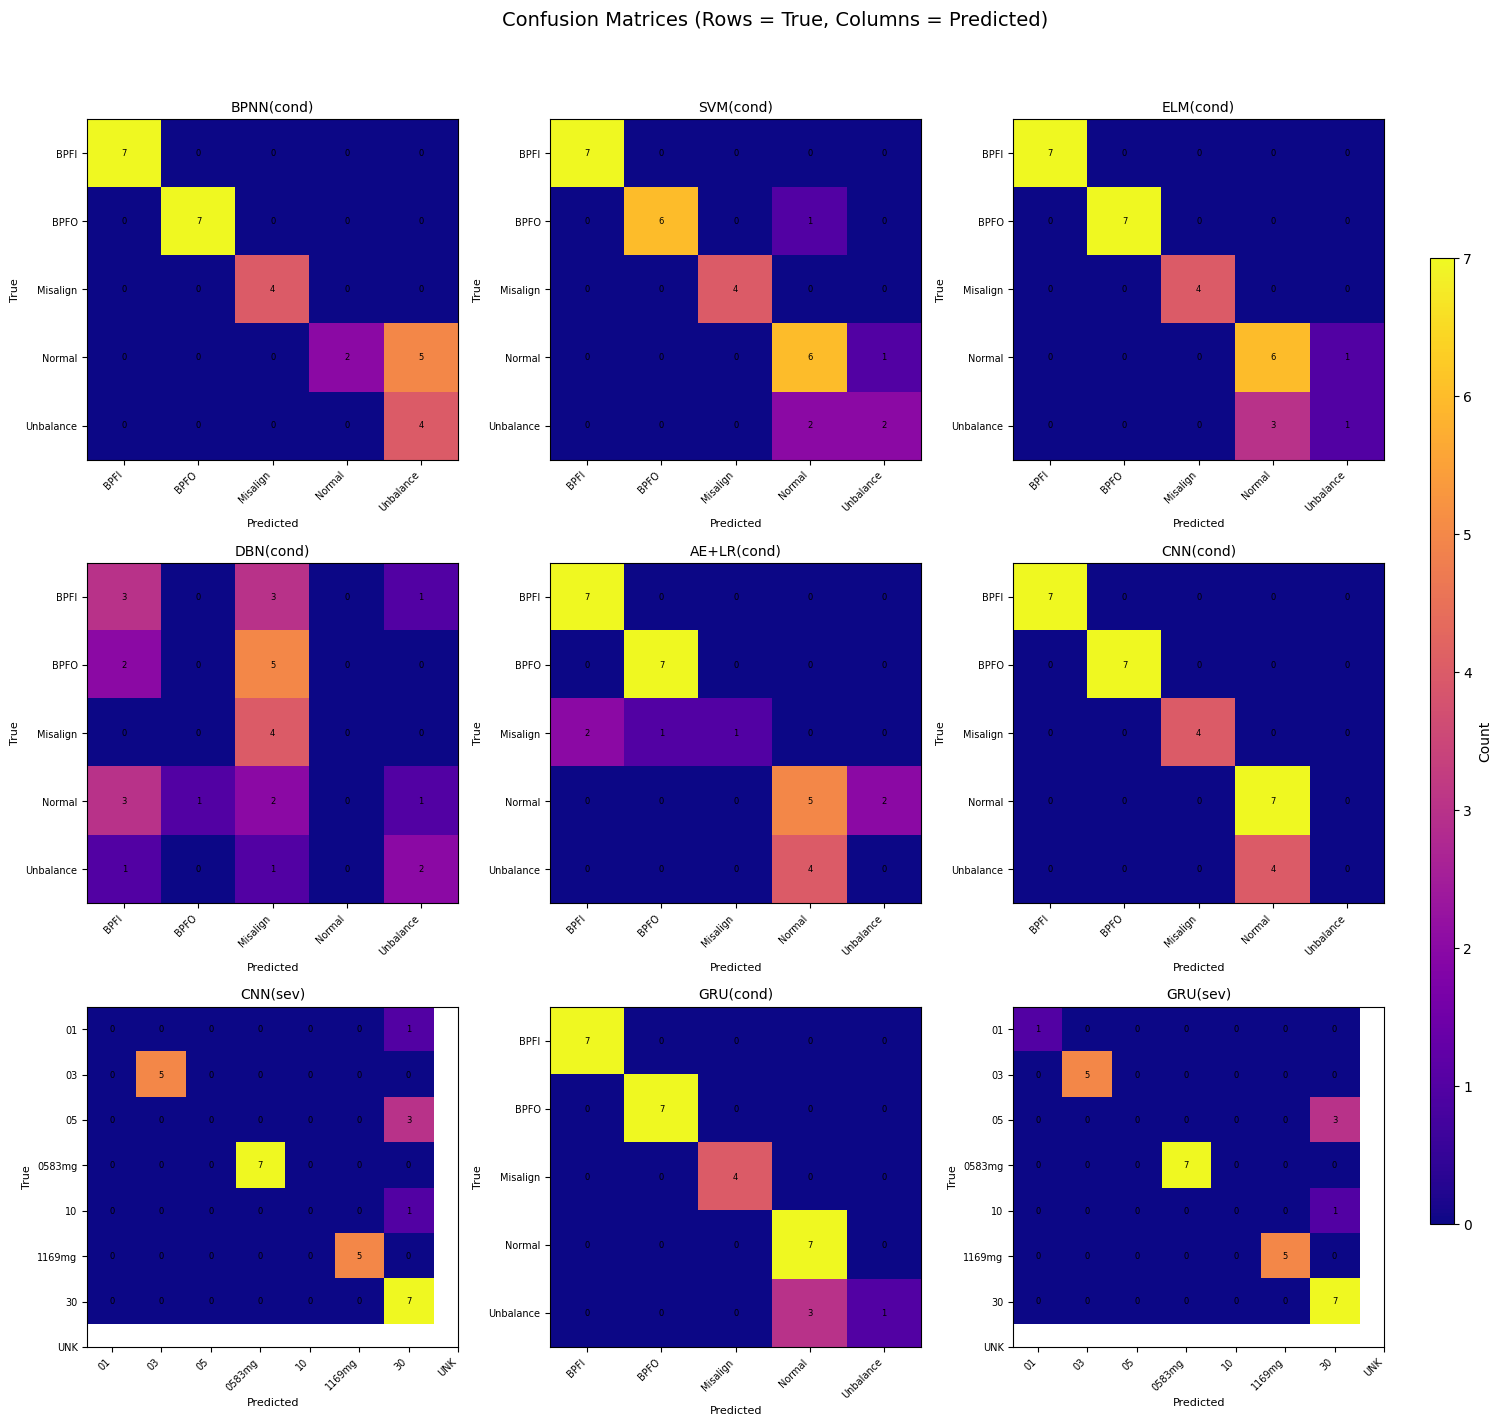

Saved confusion matrix grid: metrics_plots\confusions_grid.png


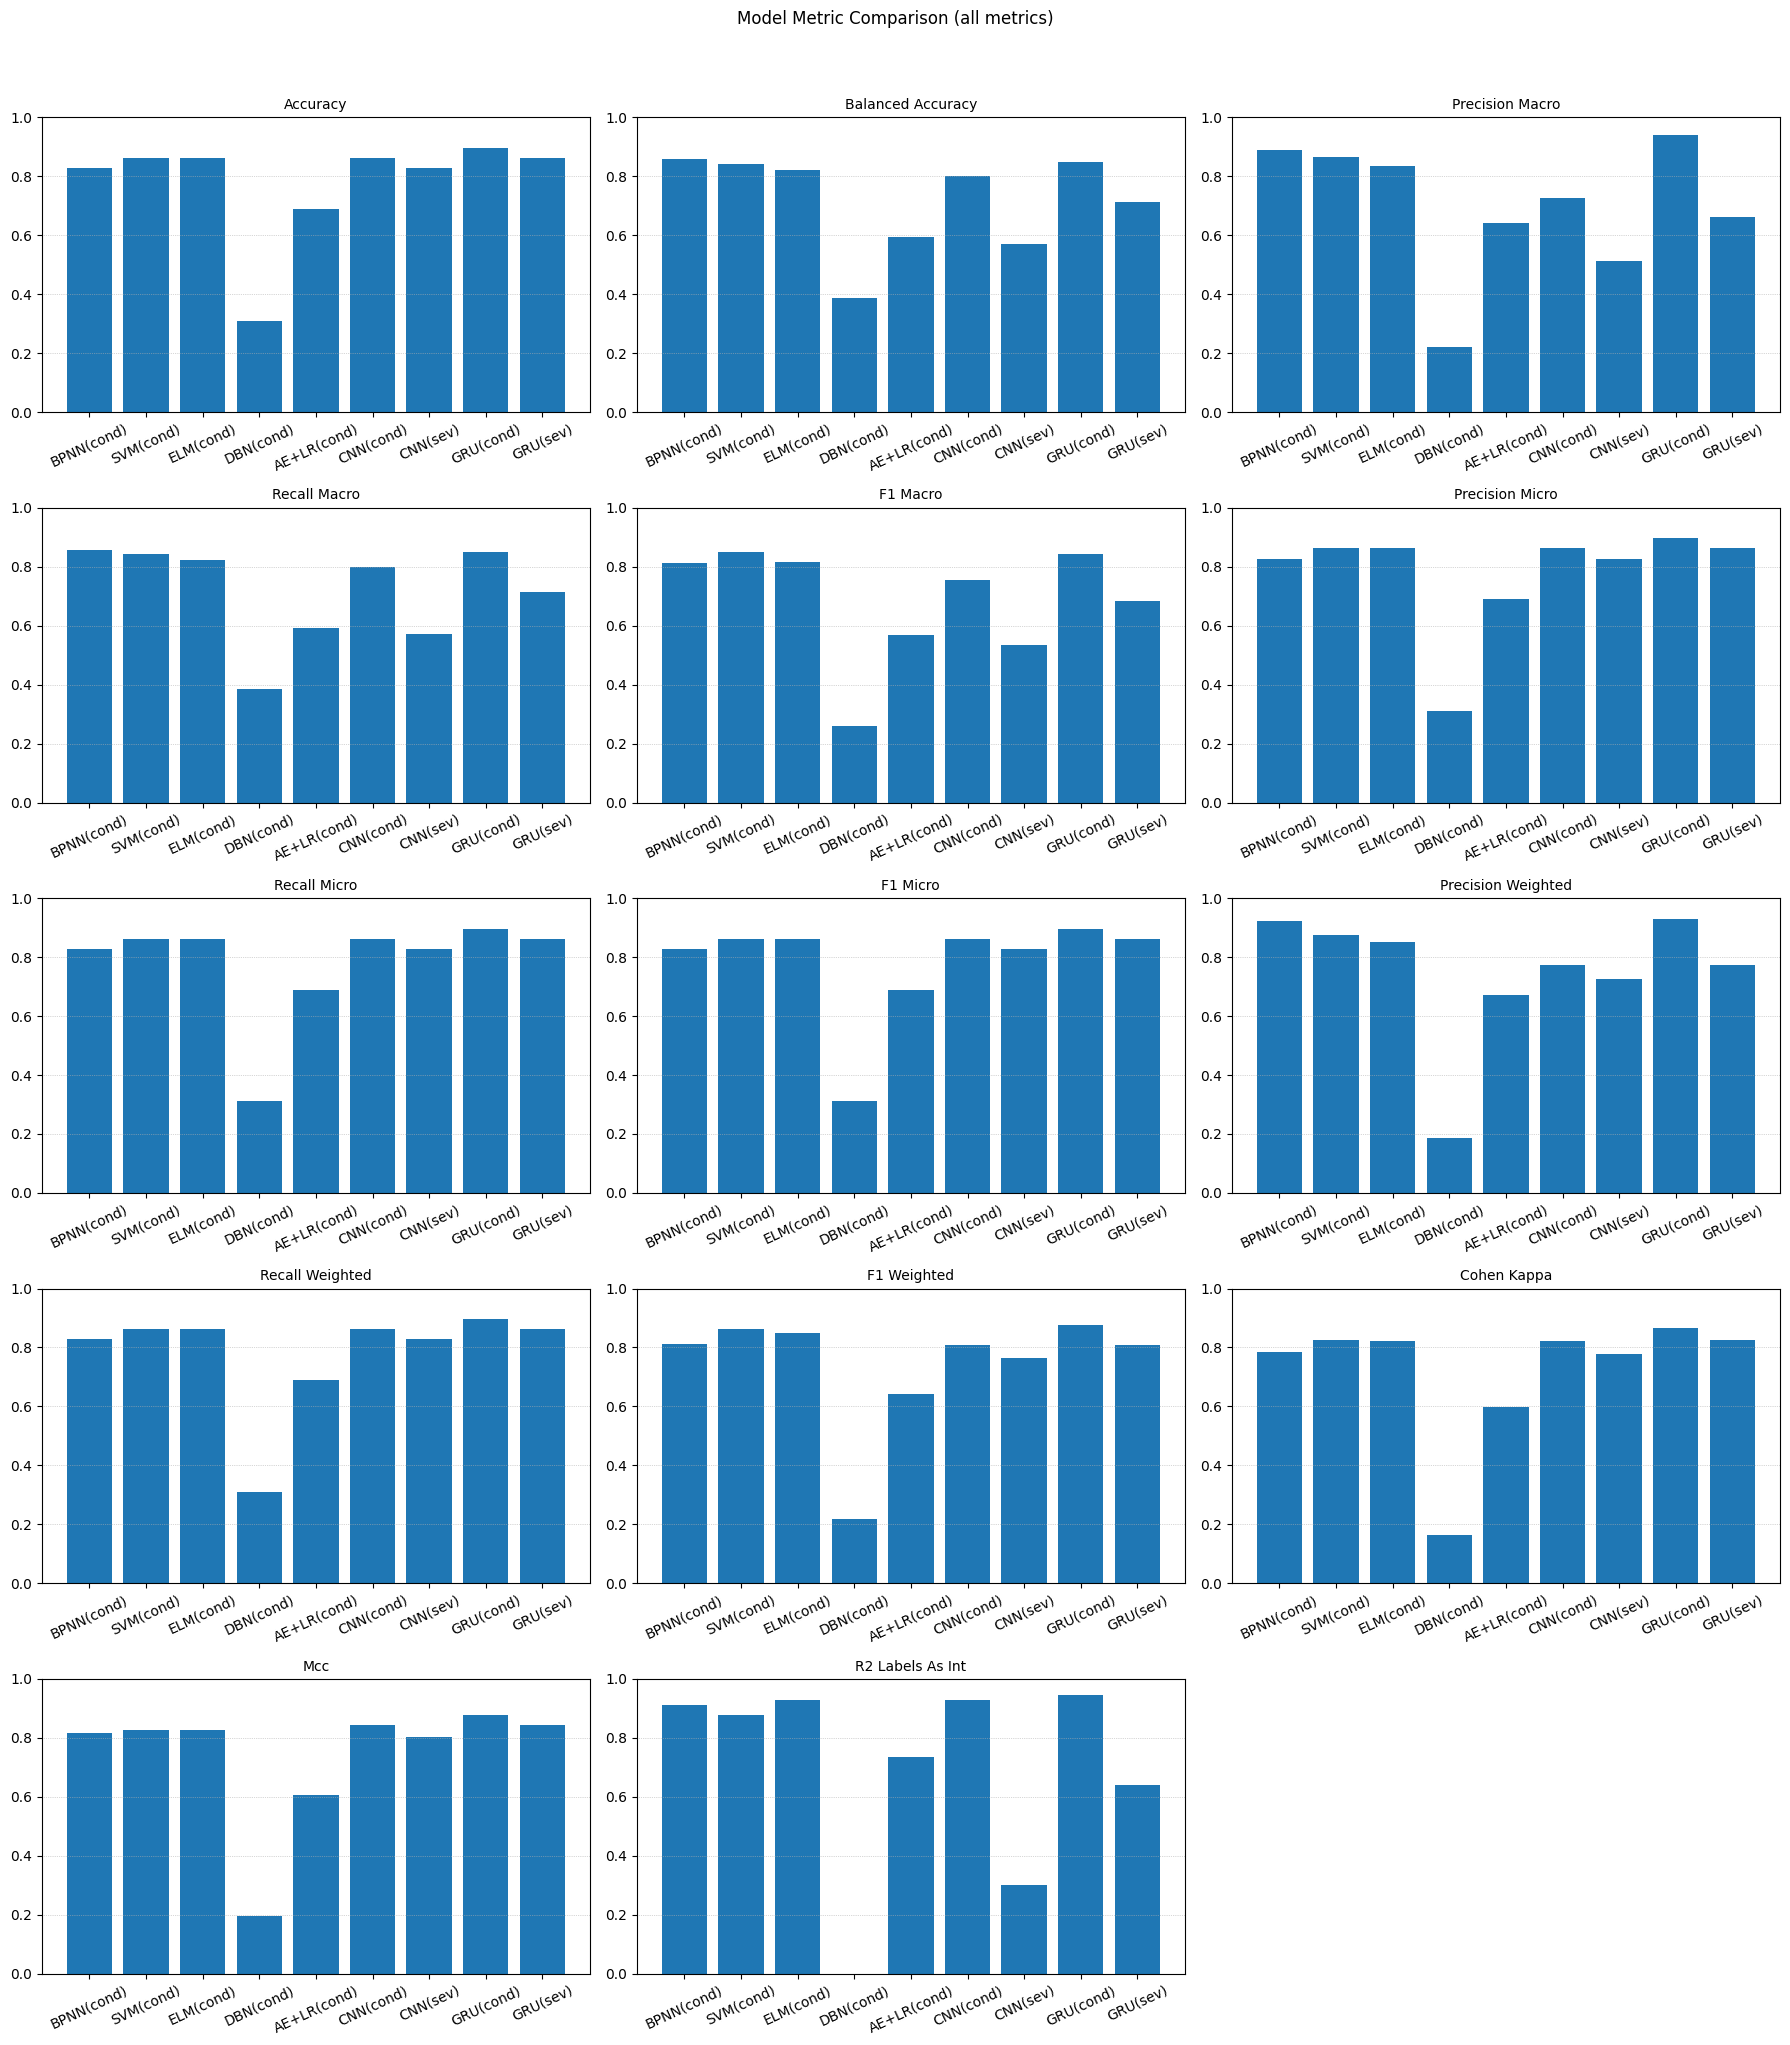

Saved metrics histograms grid: metrics_plots\histograms_grid.png


In [13]:
# ==== Post-run plotting cell ====
# Uses variables from the previous run:
# - metric_table: Dict[str, Dict[str, float]] mapping metric -> {model_label -> value}
# - confusion matrices & labels:
#     cm_mlp, cm_svm, cm_elm, cm_dbn, cm_ae
#     cm_cnn_c, cm_cnn_s, cm_gru_c, cm_gru_s
#     conditions, severities
# If you renamed variables in your run, adjust the dicts below accordingly.

import os
import math
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("metrics_plots", exist_ok=True)

# ---- Collect confusion matrices from the previous cell's variables ----
confusions = {
    "BPNN(cond)": {"cm": cm_mlp,   "labels": conditions},
    "SVM(cond)":  {"cm": cm_svm,   "labels": conditions},
    "ELM(cond)":  {"cm": cm_elm,   "labels": conditions},
    "DBN(cond)":  {"cm": cm_dbn,   "labels": conditions},
    "AE+LR(cond)":{"cm": cm_ae,    "labels": conditions},
    "CNN(cond)":  {"cm": cm_cnn_c, "labels": conditions},
    "CNN(sev)":   {"cm": cm_cnn_s, "labels": severities},
    "GRU(cond)":  {"cm": cm_gru_c, "labels": conditions},
    "GRU(sev)":   {"cm": cm_gru_s, "labels": severities},
}

# ---- Helper to draw a single confusion matrix ----
# ---------- 5) Plot all confusion matrices in one figure (clean layout) ----------
def draw_confusion(ax, cm, labels, title):
    im = ax.imshow(cm,cmap="plasma", aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    # overlay counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=6)
    return im

n = len(confusions)
cols = 3
rows = math.ceil(n / cols)
fig_cm, axes = plt.subplots(rows, cols, figsize=(cols*5.2, rows*4.6))
axes = np.array(axes).reshape(rows, cols)

ims = []
for idx, (name, payload) in enumerate(confusions.items()):
    r, c = divmod(idx, cols)
    im = draw_confusion(axes[r, c], payload["cm"], payload["labels"], name)
    ims.append(im)

# disable empty axes
for idx in range(n, rows*cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis("off")

# unify color scale
vmin = min(p["cm"].min() for p in confusions.values())
vmax = max(p["cm"].max() for p in confusions.values())
for im in ims:
    im.set_clim(vmin=vmin, vmax=vmax)

# Add ONE clean colorbar on the right
cbar_ax = fig_cm.add_axes([0.92, 0.15, 0.015, 0.7])  # (left, bottom, width, height)
cbar = fig_cm.colorbar(ims[0], cax=cbar_ax)
cbar.set_label("Count", fontsize=10)

fig_cm.suptitle("Confusion Matrices (Rows = True, Columns = Predicted)", fontsize=14, y=1.03)
fig_cm.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
confusions_grid_path = os.path.join("metrics_plots", "confusions_grid.png")
fig_cm.savefig(confusions_grid_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix grid: {confusions_grid_path}")

# ---- 2) Plot ALL metric histograms (bar charts) in ONE image (multi-subplot) ----
# metric_table: {metric -> {model_label -> score}}
metrics = list(metric_table.keys())

# For a readable grid, use up to 3 columns
cols = 3
rows = math.ceil(len(metrics) / cols)
fig_hist, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = np.array(axes).reshape(rows, cols)

for i, metric in enumerate(metrics):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    model_vals = metric_table[metric]
    labels = list(model_vals.keys())
    vals = [model_vals[k] for k in labels]
    ax.bar(labels, vals)
    ax.set_title(metric.replace("_", " ").title(), fontsize=10)
    ax.tick_params(axis='x', labelrotation=25)
    ax.set_ylim(0, 1 if "accuracy" in metric.lower() or "f1" in metric.lower() or
                    "precision" in metric.lower() or "recall" in metric.lower() or
                    "balanced" in metric.lower() else max(1.0, max(vals)+0.05))
    ax.grid(axis="y", linestyle=":", linewidth=0.5)

# turn off any leftover empty subplots
for idx in range(len(metrics), rows*cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis("off")

fig_hist.suptitle("Model Metric Comparison (all metrics)", fontsize=12, y=1.02)
fig_hist.tight_layout()
histograms_grid_path = os.path.join("metrics_plots", "histograms_grid.png")
fig_hist.savefig(histograms_grid_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved metrics histograms grid: {histograms_grid_path}")


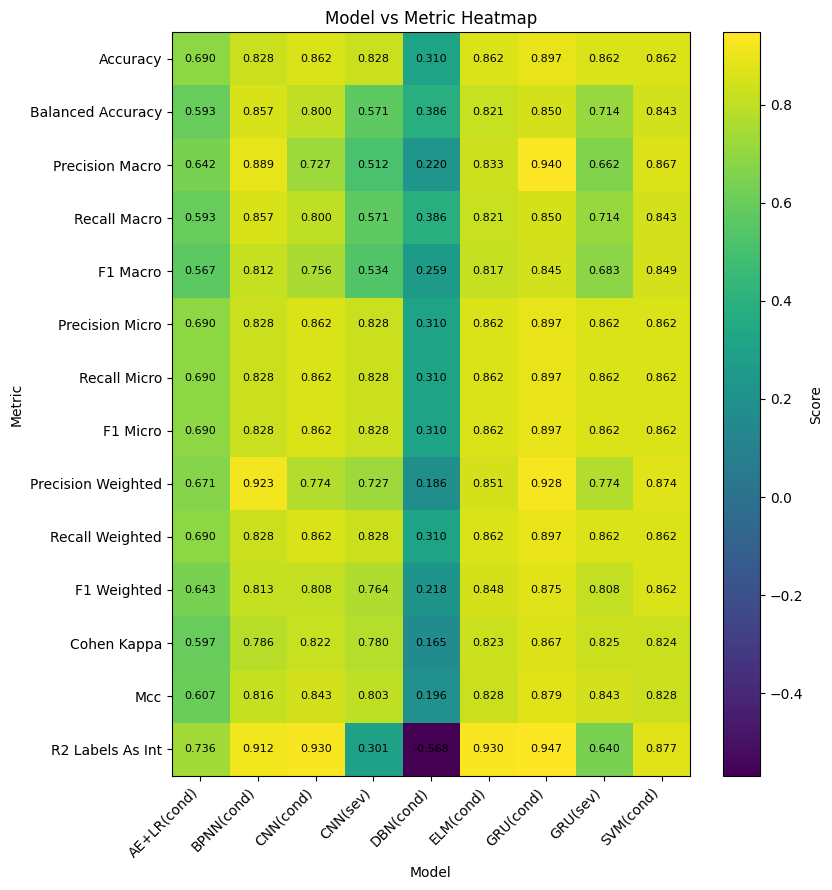

Saved heatmap: metrics_plots\metrics_heatmap.png


In [16]:
# This cell generates:
# 1) A heatmap of model vs. metric from `metric_table`
# 2) A Radar (Spider) chart comparing models (per-metric min–max normalized)
#
# Assumptions:
# - `metric_table` exists: Dict[str, Dict[str, float]] mapping metric -> {model_label -> value}
# - We avoid seaborn and use matplotlib only (as required).
# - The radar chart normalizes each metric across models to [0,1] so mixed-scale metrics are comparable.
#
# Outputs are saved into /mnt/data/metrics_plots and displayed inline.

import os
import math
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
base_dir = "metrics_plots"
os.makedirs(base_dir, exist_ok=True)

# ---- Convert metric_table to arrays ----
# Preserve a deterministic ordering
metrics = list(metric_table.keys())
# Build a canonical model order across all metrics
model_names = sorted({m for metric in metrics for m in metric_table[metric].keys()})

# Fill matrix (metrics x models), using NaN if a (metric, model) is missing
data = np.full((len(metrics), len(model_names)), np.nan, dtype=float)
for i, metric in enumerate(metrics):
    for j, model in enumerate(model_names):
        val = metric_table[metric].get(model, np.nan)
        data[i, j] = float(val) if val is not None else np.nan

# ---- 1) HEATMAP (Model vs Metric) ----
fig_hm = plt.figure(figsize=(max(6, 0.6*len(model_names)+3), max(5, 0.5*len(metrics)+2)))
ax_hm = fig_hm.add_subplot(111)

# Replace NaNs for colormap range computation (keep NaNs for mask/annotation clarity)
finite_vals = data[np.isfinite(data)]
if finite_vals.size == 0:
    vmin, vmax = 0.0, 1.0
else:
    vmin, vmax = float(np.nanmin(data)), float(np.nanmax(data))

im = ax_hm.imshow(data, aspect="auto", vmin=vmin, vmax=vmax)
ax_hm.set_xticks(np.arange(len(model_names)))
ax_hm.set_yticks(np.arange(len(metrics)))
ax_hm.set_xticklabels(model_names, rotation=45, ha="right")
ax_hm.set_yticklabels([m.replace("_", " ").title() for m in metrics])
ax_hm.set_xlabel("Model")
ax_hm.set_ylabel("Metric")
ax_hm.set_title("Model vs Metric Heatmap")

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isfinite(val):
            txt = f"{val:.3f}"
        else:
            txt = "—"
        ax_hm.text(j, i, txt, ha="center", va="center", fontsize=8)

cbar = fig_hm.colorbar(im)
cbar.set_label("Score")

heatmap_path = os.path.join(base_dir, "metrics_heatmap.png")
fig_hm.tight_layout()
fig_hm.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved heatmap: {heatmap_path}")